In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import CustomObjectScope
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras import models, layers, regularizers


In [2]:
np.random.seed(42)

In [3]:
smooth = 1e-15
def dice_coef(y_true, y_pred):
    y_true = tf.keras.layers.Flatten()(y_true)
    y_pred = tf.keras.layers.Flatten()(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [4]:
H = 256
W = 256

def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)
create_dir("files")

In [5]:
def load_dataset(path, split=0.2):
    images = sorted(glob(os.path.join(path, "images", "*.png")))
    masks = sorted(glob(os.path.join(path, "masks", "*.png")))

    split_size = int(len(images) * split)

    train_x, valid_x = train_test_split(images, test_size=split_size, random_state=42)
    train_y, valid_y = train_test_split(masks, test_size=split_size, random_state=42)
 
    train_x, test_x = train_test_split(train_x, test_size=split_size, random_state=42)
    train_y, test_y = train_test_split(train_y, test_size=split_size, random_state=42)

    return (train_x, train_y), (valid_x, valid_y), (test_x, test_y)

In [6]:
def read_image(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_COLOR)
    x = cv2.resize(x, (W, H))
    x = x / 255.0
    x = x.astype(np.float32)
    return x

def read_mask(path):
    path = path.decode()
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  ## (h, w)
    x = cv2.resize(x, (W, H))   ## (h, w)
    x = x / 255.0               ## (h, w)
    x = x.astype(np.float32)    ## (h, w)
    x = np.expand_dims(x, axis=-1)## (h, w, 1)
    return x

In [7]:
def tf_parse(x, y):
    def _parse(x, y):
        x = read_image(x)
        y = read_mask(y)
        return x, y

    x, y = tf.numpy_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(X, Y, batch=2):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.map(tf_parse)
    dataset = dataset.batch(batch)
    dataset = dataset.prefetch(10)
    return dataset

In [8]:
batch_size = 8
lr = 1e-4
num_epochs = 100
dataset_path="/kaggle/input/brain-tumor-segmentation"
model_path = os.path.join("files", "attention_res_unet_best.keras")
csv_path = os.path.join("files", "log.csv")

In [9]:
(train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset(dataset_path)

print(f"Train: ({len(train_x)},{len(train_y)})")
print(f"Valid: ({len(valid_x)},{len(valid_x)})")
print(f"Test: ({len(test_x)},{len(test_x)})")

Train: (1840,1840)
Valid: (612,612)
Test: (612,612)


In [10]:
train_dataset = tf_dataset(train_x, train_y, batch=batch_size)
valid_dataset = tf_dataset(valid_x, valid_y, batch=batch_size)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation, 
                                     MaxPooling2D, UpSampling2D, Concatenate, 
                                     Input, Add, Multiply)
from tensorflow.keras.models import Model

def conv_block(x, filters):
    """Residual convolutional block"""
    shortcut = x
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Conv2D(filters, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    shortcut = Conv2D(filters, (1, 1), padding="same")(shortcut)
    x = Add()([x, shortcut])
    x = Activation("relu")(x)
    return x

def attention_gate(x, g):
    """Attention Gate"""
    filters = x.shape[-1]
    g = Conv2D(filters, (1, 1), padding="same")(g)
    x = Conv2D(filters, (1, 1), padding="same")(x)
    attn = Add()([x, g])
    attn = Activation("relu")(attn)
    attn = Conv2D(1, (1, 1), padding="same", activation="sigmoid")(attn)
    return Multiply()([x, attn])

def attention_resunet(input_shape=(256, 256, 3), num_classes=1):
    inputs = Input(input_shape)
    
    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = conv_block(p1, 128)
    p2 = MaxPooling2D((2, 2))(c2)
    
    c3 = conv_block(p2, 256)
    p3 = MaxPooling2D((2, 2))(c3)
    
    c4 = conv_block(p3, 512)
    p4 = MaxPooling2D((2, 2))(c4)
    
    # Bottleneck
    c5 = conv_block(p4, 1024)
    
    # Decoder
    u6 = UpSampling2D((2, 2))(c5)
    a6 = attention_gate(c4, u6)
    u6 = Concatenate()([u6, a6])
    c6 = conv_block(u6, 512)
    
    u7 = UpSampling2D((2, 2))(c6)
    a7 = attention_gate(c3, u7)
    u7 = Concatenate()([u7, a7])
    c7 = conv_block(u7, 256)
    
    u8 = UpSampling2D((2, 2))(c7)
    a8 = attention_gate(c2, u8)
    u8 = Concatenate()([u8, a8])
    c8 = conv_block(u8, 128)
    
    u9 = UpSampling2D((2, 2))(c8)
    a9 = attention_gate(c1, u9)
    u9 = Concatenate()([u9, a9])
    c9 = conv_block(u9, 64)
    
    outputs = Conv2D(num_classes, (1, 1), activation="sigmoid")(c9)
    
    return Model(inputs, outputs)

# Create model
model = attention_resunet()
model.compile(loss=dice_loss, optimizer=Adam(lr), metrics=[dice_coef,'accuracy'])
model.summary()


Model: "functional"

 Trainable params: 34,182,021 (130.39 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
callbacks = [
        ModelCheckpoint(model_path, verbose=1, save_best_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-7, verbose=1),
        CSVLogger(csv_path),
        EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ]

In [13]:
model.fit(
        train_dataset,
        epochs=num_epochs,
        validation_data=valid_dataset,
        callbacks=callbacks,
        verbose=1,
    )

Epoch 1/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.9029 - dice_coef: 0.3463 - loss: 0.6537
Epoch 1: val_loss improved from inf to 0.99523, saving model to files/attention_res_unet_best.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 140s 404ms/step - accuracy: 0.9032 - dice_coef: 0.3467 - loss: 0.6533 - val_accuracy: 0.9816 - val_dice_coef: 0.0047 - val_loss: 0.9952 - learning_rate: 1.0000e-04
Epoch 2/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9850 - dice_coef: 0.5666 - loss: 0.4334
Epoch 2: val_loss improved from 0.99523 to 0.71131, saving model to files/attention_res_unet_best.keras
230/230 ━━━━━━━━━━━━━━━━━━━━ 76s 331ms/step - accuracy: 0.9850 - dice_coef: 0.5667 - loss: 0.4333 - val_accuracy: 0.9844 - val_dice_coef: 0.2885 - val_loss: 0.7113 - learning_rate: 1.0000e-04
Epoch 3/100
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9877 - dice_coef: 0.6388 - loss: 0.3612
Epoch 3: val_loss improved from 0.71131 to 0.33872, saving model to files/attention_

In [14]:
import pandas as pd
metrics = pd.read_csv("/kaggle/working/files/log.csv")
metrics

,epoch,accuracy,dice_coef,learning_rate,loss,val_accuracy,val_dice_coef,val_loss
0,0,0.964321,0.449512,1.000000e-04,0.550488,0.981617,0.004736,0.995235
1,1,0.986205,0.584092,1.000000e-04,0.415908,0.984407,0.288514,0.711307
2,2,0.988615,0.658029,1.000000e-04,0.341971,0.989484,0.661414,0.338718
3,3,0.989689,0.694580,1.000000e-04,0.305420,0.985878,0.645070,0.354262
4,4,0.990631,0.723814,1.000000e-04,0.276185,0.987767,0.656606,0.343353
5,5,0.991609,0.755741,1.000000e-04,0.244259,0.988726,0.677080,0.322827
6,6,0.992568,0.784880,1.000000e-04,0.215120,0.990543,0.709641,0.289935
7,7,0.993209,0.805182,1.000000e-04,0.194818,0.991387,0.746073,0.253652
8,8,0.993100,0.801253,1.000000e-04,0.198747,0.991012,0.707125,0.290076
9,9,0.993791,0.824462,1.000000e-04,0.175538,0.988421,0.655951,0.344560


<Axes: >

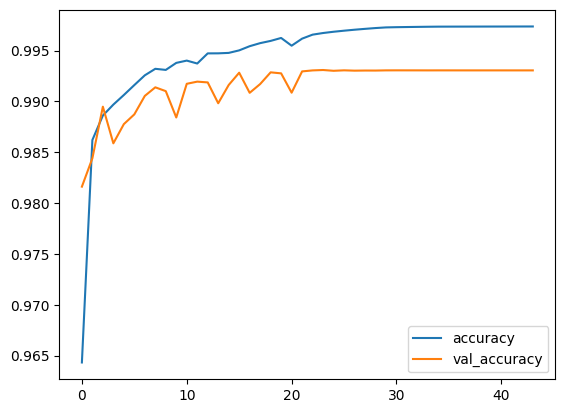

In [15]:
metrics[['accuracy','val_accuracy']].plot()

<Axes: >

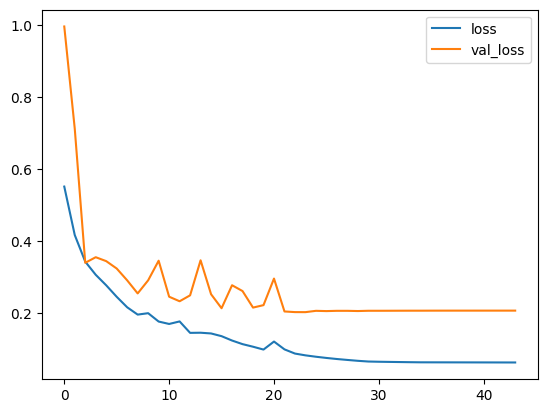

In [16]:
metrics[['loss','val_loss']].plot()

In [17]:
test_dataset = tf_dataset(test_x, test_y, batch=batch_size)

In [18]:
results = model.evaluate(test_dataset)

# Print Results
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[2]:.4f}")
print(f"Test Dice Coefficient: {results[1]*100:.4f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 18s 227ms/step - accuracy: 0.9930 - dice_coef: 0.7976 - loss: 0.2024
Test Loss: 0.2111
Test Accuracy: 0.9931
Test Dice Coefficient: 78.9832


In [19]:
from tqdm import tqdm
SCORE = []
for x, y in tqdm(zip(test_x, test_y), total=len(test_y)):
    """ Extracting the name """
    name = x.split("/")[-1]

    """ Reading the image """
    image = cv2.imread(x, cv2.IMREAD_COLOR) ## [H, w, 3]
    image = cv2.resize(image, (W, H))       ## [H, w, 3]
    x = image/255.0                         ## [H, w, 3]
    x = np.expand_dims(x, axis=0)           ## [1, H, w, 3]

    """ Reading the mask """
    mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (W, H))

    """ Prediction """
    y_pred = model.predict(x, verbose=0)[0]
    y_pred = np.squeeze(y_pred, axis=-1)
    y_pred = y_pred >= 0.5
    y_pred = y_pred.astype(np.int32)
    '''
    """ Saving the prediction """
    save_image_path = os.path.join("results", name)
    save_results(image, mask, y_pred, save_image_path)
    '''

    """ Flatten the array """
    mask = mask/255.0
    mask = (mask > 0.5).astype(np.int32).flatten()
    y_pred = y_pred.flatten()

    """ Calculating the metrics values """
    f1_value = f1_score(mask, y_pred, labels=[0, 1], average="binary")
    jac_value = jaccard_score(mask, y_pred, labels=[0, 1], average="binary")
    recall_value = recall_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)
    precision_value = precision_score(mask, y_pred, labels=[0, 1], average="binary", zero_division=0)
    SCORE.append([name, f1_value, jac_value, recall_value, precision_value])

""" Metrics values """
score = [s[1:]for s in SCORE]
score = np.mean(score, axis=0)
print(f"F1: {score[0]:0.5f}")
print(f"Jaccard: {score[1]:0.5f}")
print(f"Recall: {score[2]:0.5f}")
print(f"Precision: {score[3]:0.5f}")

df = pd.DataFrame(SCORE, columns=["Image", "F1", "Jaccard", "Recall", "Precision"])
df.to_csv("files/score.csv", index=None)

100%|██████████| 612/612 [01:45<00:00,  5.81it/s]

F1: 0.73724
Jaccard: 0.65304
Recall: 0.72949
Precision: 0.80565


In [20]:
scores = pd.read_csv("/kaggle/working/files/score.csv")
scores

,Image,F1,Jaccard,Recall,Precision
0,833.png,0.926523,0.863105,0.910211,0.943431
1,2069.png,0.830022,0.709434,1.000000,0.709434
2,3038.png,0.528872,0.359501,0.763240,0.404624
3,1169.png,0.949381,0.903640,0.909483,0.992941
4,501.png,0.963623,0.929799,0.955817,0.971557
...,...,...,...,...,...
607,1675.png,0.834990,0.716724,0.853659,0.817121
608,429.png,0.967684,0.937391,0.960784,0.974684
609,344.png,0.951915,0.908243,0.916797,0.989831
610,2667.png,0.875000,0.777778,0.781132,0.994509
